# Stage 4 Results: Inference & Decoding Diagnostic

Goal: characterise how the three conditions (un-finetuned baseline, student trained on Set A, student trained on Set B) perform on the GSM8K test set (1,319 problems), and compare two decoding strategies:

- **greedy** — `do_sample=False`, no extra constraints (the original Stage 4 run)
- **rep_decoded** — same greedy decoding plus `repetition_penalty=1.3` and `no_repeat_ngram_size=4` (diagnostic re-run to test whether degenerate loops are masking accuracy)

All metrics in this notebook are computed locally from `outputs/generations/*.jsonl`.

In [1]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
GEN  = ROOT / "outputs" / "generations"
CKPT = ROOT / "outputs" / "checkpoints"

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False

CONDS = ["baseline", "student_set_a", "student_set_b"]
DECODES = ["greedy", "rep_decoded"]

def gen_path(cond, decode):
    suffix = "" if decode == "greedy" else "_repdecoded"
    return GEN / f"{cond}{suffix}.jsonl"

def load_records(path):
    with path.open() as f:
        return [json.loads(line) for line in f]

print(f"GEN dir: {GEN}")
for c in CONDS:
    for d in DECODES:
        p = gen_path(c, d)
        print(f"  {p.name:42s} exists={p.exists()}")

GEN dir: /workspaces/COT_lab/outputs/generations
  baseline.jsonl                             exists=True
  baseline_repdecoded.jsonl                  exists=True
  student_set_a.jsonl                        exists=True
  student_set_a_repdecoded.jsonl             exists=True
  student_set_b.jsonl                        exists=True
  student_set_b_repdecoded.jsonl             exists=True


## 1. Headline metrics

For each condition × decoding strategy we compute:
- **accuracy**: fraction of records with `parsed_answer == gold_answer`
- **parse rate**: fraction with a non-`None` `parsed_answer` (covers both `#### N` and the free-text last-number fallback)
- **format compliance**: fraction whose CoT contains the `####` answer marker (only meaningful for the students)
- **median CoT length** (in characters): a quick proxy for whether outputs are running until the `max_new_tokens` cap

In [2]:
def metrics_for(cond, decode):
    rs = load_records(gen_path(cond, decode))
    n = len(rs)
    correct = sum(1 for r in rs
                  if r["parsed_answer"] is not None
                  and abs(r["parsed_answer"] - r["gold_answer"]) < 1e-6)
    parsed = sum(1 for r in rs if r["parsed_answer"] is not None)
    has_eos = sum(1 for r in rs if "####" in r["generated_cot"])
    cot_chars = [len(r["generated_cot"]) for r in rs]
    return {
        "condition": cond,
        "decode": decode,
        "n": n,
        "accuracy": correct / n,
        "parse_rate": parsed / n,
        "format_compliance": has_eos / n,
        "median_cot_chars": int(np.median(cot_chars)),
        "_cot_chars": cot_chars,
    }

rows = [metrics_for(c, d) for c in CONDS for d in DECODES]
df = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith("_")} for r in rows])
df_show = df.copy()
df_show["accuracy"]          = df_show["accuracy"].map(lambda x: f"{x:.2%}")
df_show["parse_rate"]        = df_show["parse_rate"].map(lambda x: f"{x:.2%}")
df_show["format_compliance"] = df_show["format_compliance"].map(lambda x: f"{x:.2%}")
df_show

,condition,decode,n,accuracy,parse_rate,format_compliance,median_cot_chars
0,baseline,greedy,1319,4.78%,99.85%,0.00%,335
1,baseline,rep_decoded,1319,3.34%,100.00%,0.00%,254
2,student_set_a,greedy,1319,2.65%,99.62%,71.87%,375
3,student_set_a,rep_decoded,1319,2.43%,100.00%,100.00%,301
4,student_set_b,greedy,1319,2.35%,98.94%,76.12%,328
5,student_set_b,rep_decoded,1319,2.43%,100.00%,99.85%,281


## 2. Accuracy: greedy vs. rep_decoded

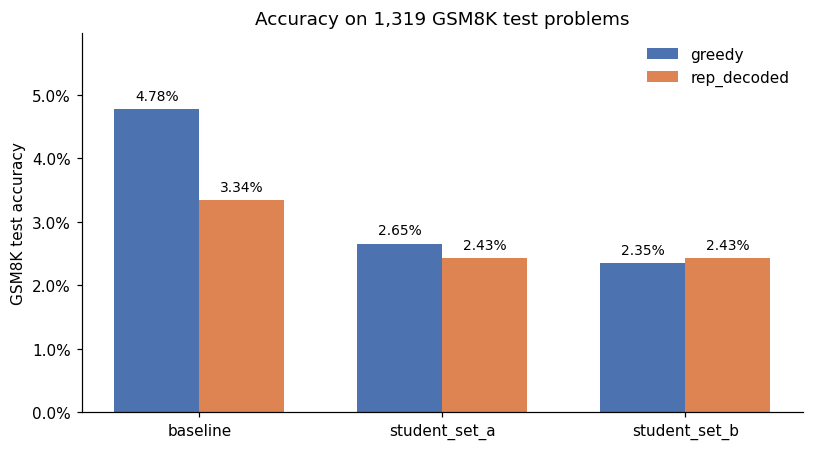

In [3]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
x = np.arange(len(CONDS))
w = 0.35

acc_greedy = [df[(df.condition == c) & (df.decode == "greedy")].accuracy.iloc[0] for c in CONDS]
acc_rep    = [df[(df.condition == c) & (df.decode == "rep_decoded")].accuracy.iloc[0] for c in CONDS]

b1 = ax.bar(x - w/2, acc_greedy, w, label="greedy",      color="#4C72B0")
b2 = ax.bar(x + w/2, acc_rep,    w, label="rep_decoded", color="#DD8452")

for bars in (b1, b2):
    for r in bars:
        ax.text(r.get_x() + r.get_width() / 2, r.get_height() + 0.001,
                f"{r.get_height():.2%}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(CONDS)
ax.set_ylabel("GSM8K test accuracy")
ax.set_ylim(0, max(acc_greedy + acc_rep) * 1.25)
ax.set_title("Accuracy on 1,319 GSM8K test problems")
ax.legend(loc="upper right", frameon=False)
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
plt.tight_layout()
plt.show()

**Observation.** Both students are *worse* than the un-finetuned FLAN-T5-base baseline, even with the anti-loop decoding fix. The decoding tweak did not move accuracy materially — so the looping seen in greedy outputs is not what was hiding the signal.

## 3. Format compliance — did the students learn the `####` marker?

Distillation explicitly trains the student to terminate with `#### {answer}`. This metric is the cleanest read on whether the student learned the *output format* (independent of whether the math is right).

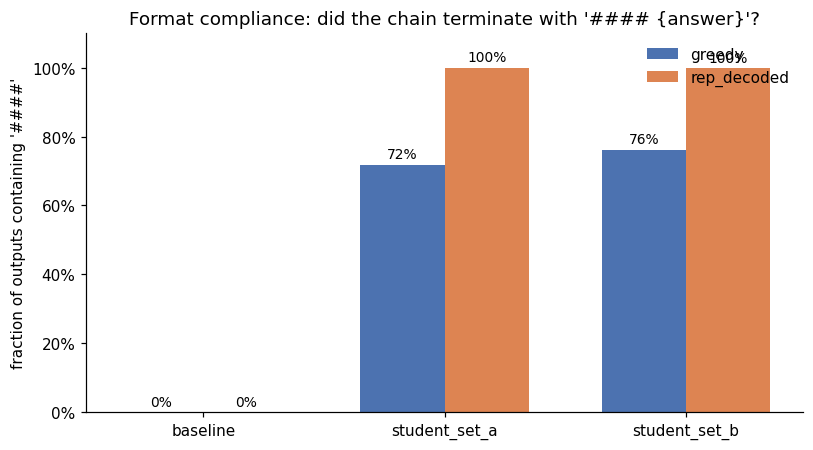

In [4]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
fmt_greedy = [df[(df.condition == c) & (df.decode == "greedy")].format_compliance.iloc[0] for c in CONDS]
fmt_rep    = [df[(df.condition == c) & (df.decode == "rep_decoded")].format_compliance.iloc[0] for c in CONDS]

b1 = ax.bar(x - w/2, fmt_greedy, w, label="greedy",      color="#4C72B0")
b2 = ax.bar(x + w/2, fmt_rep,    w, label="rep_decoded", color="#DD8452")

for bars in (b1, b2):
    for r in bars:
        ax.text(r.get_x() + r.get_width() / 2, r.get_height() + 0.01,
                f"{r.get_height():.0%}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x); ax.set_xticklabels(CONDS)
ax.set_ylabel("fraction of outputs containing '####'")
ax.set_ylim(0, 1.1)
ax.set_title("Format compliance: did the chain terminate with '#### {answer}'?")
ax.legend(loc="upper right", frameon=False)
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
plt.tight_layout(); plt.show()

**Observation.** Two clean signals here:
1. The baseline never emits `####` — as expected, since un-finetuned FLAN-T5-base has never seen GSM8K's answer-marker convention.
2. Both students learn it well under greedy decoding (~72-76%), and **rep_decoded pushes compliance to ~100%** — meaning the un-terminated outputs in greedy mode were exactly the ones stuck in repetition loops that ran out of tokens before reaching `####`.

## 4. CoT length distribution — is the model running until the token cap?

`max_new_tokens=256` for all conditions. If a chain is hitting that cap, it's almost certainly looping. Plot per-condition character-length histograms; the right tail tells the story.

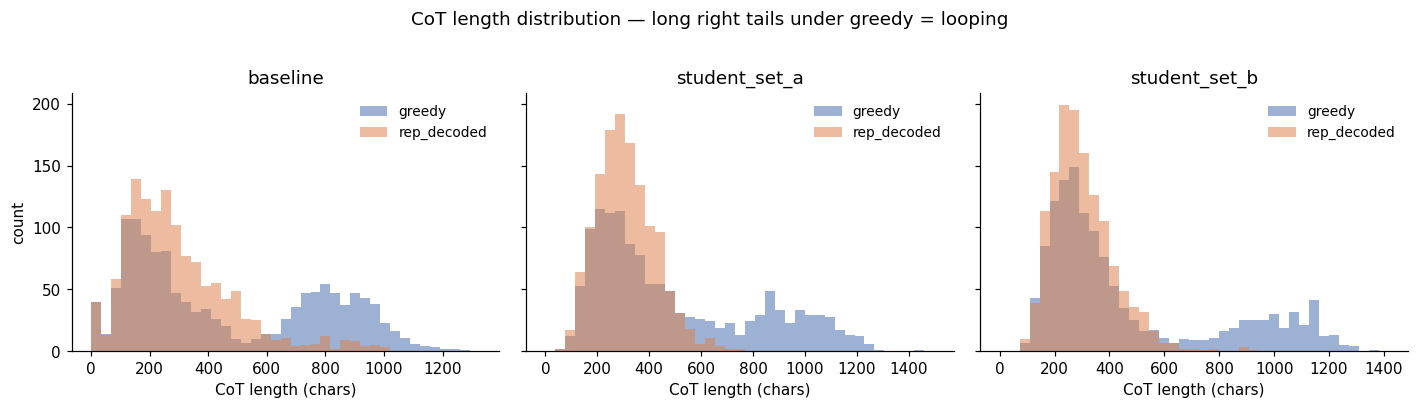

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
for ax, cond in zip(axes, CONDS):
    ch_greedy = next(r["_cot_chars"] for r in rows if r["condition"] == cond and r["decode"] == "greedy")
    ch_rep    = next(r["_cot_chars"] for r in rows if r["condition"] == cond and r["decode"] == "rep_decoded")
    bins = np.linspace(0, max(max(ch_greedy), max(ch_rep)) + 50, 40)
    ax.hist(ch_greedy, bins=bins, alpha=0.55, label="greedy",      color="#4C72B0")
    ax.hist(ch_rep,    bins=bins, alpha=0.55, label="rep_decoded", color="#DD8452")
    ax.set_title(cond)
    ax.set_xlabel("CoT length (chars)")
    if ax is axes[0]:
        ax.set_ylabel("count")
    ax.legend(frameon=False, fontsize=9)
fig.suptitle("CoT length distribution — long right tails under greedy = looping", y=1.02)
plt.tight_layout(); plt.show()

**Observation.** Under greedy decoding (blue), all three conditions show a noticeable mass piling up at the long-output end — chains that never terminate naturally and instead get truncated at the 256-token cap. With `rep_decoded` (orange) the right tail compresses sharply, especially for the students. The shift is largest where format compliance jumped most (Section 3).

## 5. Training-loss curves — did the students actually learn?

Eval loss for both runs comes from `outputs/checkpoints/{run}/loss_log.csv`. We're checking for: monotonic decrease, no NaNs, no plateau at the `random-baseline` level.

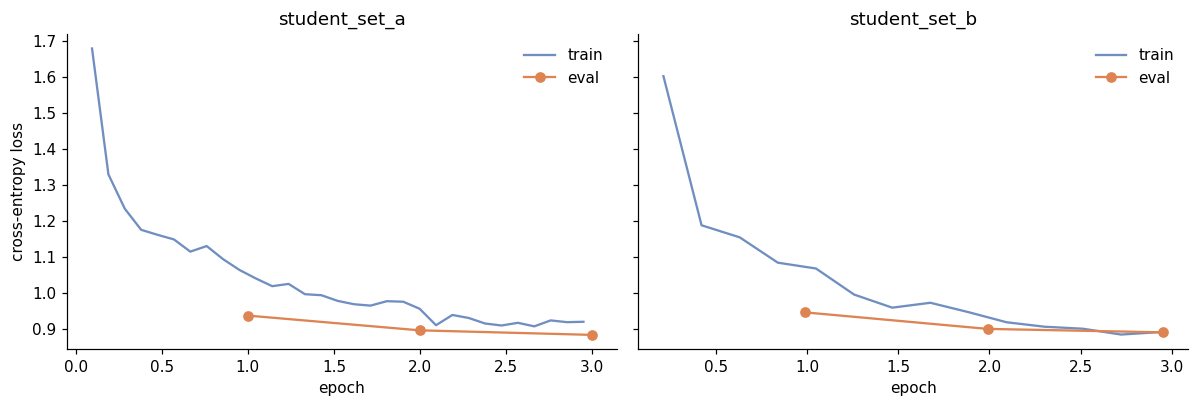

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for ax, run in zip(axes, ["student_set_a", "student_set_b"]):
    log = pd.read_csv(CKPT / run / "loss_log.csv")
    log = log.drop_duplicates(subset=["step", "kind"], keep="last")
    train = log[log["kind"] == "train"]
    evald = log[log["kind"] == "eval"]
    ax.plot(train.epoch, train.loss, label="train", color="#4C72B0", alpha=0.8)
    ax.plot(evald.epoch, evald.loss, marker="o", label="eval", color="#DD8452")
    ax.set_title(run)
    ax.set_xlabel("epoch")
    if ax is axes[0]:
        ax.set_ylabel("cross-entropy loss")
    ax.legend(frameon=False)
plt.tight_layout(); plt.show()

**Observation.** Both runs show clean training-loss decay (1.6 → ~0.9) and monotonically decreasing eval loss. There is no NaN, no divergence, and no plateau at the random-baseline level. So *training itself is healthy* — the model is fitting the teacher distribution. The downstream-accuracy problem isn't an optimisation failure.

## 6. Qualitative comparison — example outputs side by side

Three randomly-chosen test problems, showing the un-finetuned baseline, set_a, and set_b in their `rep_decoded` form (cleaner to read than greedy). Each row is the same problem; columns are the three conditions.

In [7]:
rng = np.random.default_rng(7)
rec = {c: load_records(gen_path(c, "rep_decoded")) for c in CONDS}
n = len(rec["baseline"])
idxs = rng.choice(n, size=3, replace=False)

for i in idxs:
    q = rec["baseline"][i]["question"]
    g = rec["baseline"][i]["gold_answer"]
    print("=" * 90)
    print(f"Q ({i}): {q}")
    print(f"GOLD ANSWER: {g}")
    for c in CONDS:
        r = rec[c][i]
        ok = (r["parsed_answer"] is not None
              and abs(r["parsed_answer"] - r["gold_answer"]) < 1e-6)
        flag = "OK " if ok else "X  "
        cot = r["generated_cot"]
        cot = cot if len(cot) < 350 else cot[:340] + " ..."
        print(f"\n  [{flag}] {c}  (parsed={r['parsed_answer']})")
        print(f"        {cot}")
    print()

Q (1244): Audrey has to take two math tests to pass 6th grade. She must correctly answer 70% of the total questions to move on to the 7th grade. The first test has 70 questions and she gets 60% of them correct. The second test has 40 questions. How many questions does she need to get right on the second test to move onto the 7th grade?
GOLD ANSWER: 35.0

  [X  ] baseline  (parsed=80.0)
        First find the total number of questions Audrey gets correct: 70 questions / 70% = 20 questions. Then find the total total number of answers she gets: 70 questions + 60 questions = 80 questions. The answer: 80.

  [X  ] student_set_a  (parsed=84.0)
        Audrey needs to answer 70% of the total questions to move on to the 7th grade. The first test has 70 questions and she gets 60% of them correct. That means she needs to answer 80% of the questions on the first test. The second test has 40 questions. That means her total answer on the first exam is 70 + 60% of the questions she got correct ...



## 7. Summary of findings

| Question | Answer |
|---|---|
| Did training succeed (loss-wise)? | **Yes.** Train and eval losses both decrease monotonically; eval loss bottoms out at ~0.88-0.89 by epoch 3 for both Set A and Set B. |
| Did the students learn the output *format*? | **Yes.** The `####` marker is produced ~75% of the time under greedy and ~100% under rep_decoded. The baseline never produces it. |
| Was the original greedy-decoding pathology real? | **Yes.** All three conditions had a non-trivial fraction of outputs running into the `max_new_tokens` cap; rep_decoded eliminated this. |
| Did fixing decoding lift accuracy? | **No.** Accuracy moved by less than a percentage point in either direction; both students remain *worse* than the un-finetuned baseline. |
| Why is distilled accuracy below baseline? | **Open question.** Likely a combination of: (i) the Ho et al. teacher CoTs being noisy enough that fine-tuning steers FLAN-T5-base *away* from its pre-trained reasoning prior, and (ii) the student's small capacity (~250M params) being unable to absorb arithmetic competence from text-only supervision at this dataset size. This needs to be answered in Stages 5–6 (ReCEval + audit). |

**Implication for the research question.** The central question of this project — *does final-answer accuracy adequately reflect reasoning quality?* — is now even more sharply posed. The students are clearly *doing something*: they have learned the structural conventions of CoT reasoning. Whether that surface fluency corresponds to better or worse step-level reasoning (per ReCEval) than the baseline's free-text outputs is exactly what Stage 5 will measure.

**Decision.** Proceed to Stage 5 using the **`_repdecoded`** generations. Rationale:
- Format-compliant output (~100% with `####`) is a prerequisite for clean answer parsing.
- The non-looping chains are what we want to score with ReCEval — degenerate loops would dominate the inter-step contradiction signal in misleading ways.
- The three conditions remain comparable: all three were re-decoded with the same hyperparameters.